# Hybrid control + Inverse Dynamics

#### 1. Initialize & check scene

In [1]:
import os
import sys
import numpy as np
import time
import mujoco
sys.path.append(os.path.abspath('../'))
from pp_base_mujoco.VIEWER import *
from pp_base_mujoco.UTILS import *
from pp_base_mujoco.SPEC_HELPER import *
from pp_base_mujoco.KINEMATICS import *

In [2]:
spec_helper = MjSpecHelper()
spec_helper.add_robot(
    path='../asset/panda/panda_ee_sphere.xml',
    body_name="base",
    p=(0, 0.7, 0),
    r=(0, 0, -1.57),
    # r=(0, 0, 0),
    prefix="",
    suffix="_right"
)
spec_helper.add_robot(
    path='../asset/panda/panda_ee_sphere.xml',
    body_name="base",
    p=(0, -0.7, 0),
    r=(0, 0, 1.57),
    # r=(0, 0, 0),
    prefix="",
    suffix="_left"
)
spec_helper.add_geom(
    name="box",
    type='box',
    size=(0.15, 0.15, 0.15),
    freejoint = True,
    p=(0.2, 0, 0.15),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 0.3, 0.5),
    group=1,
    # friction=(1.0, 0.005, 0.0001),
    friction=(0.3, 0.01, 0.001),
    mass=0.05
)
spec_helper.add_site(
    name="contact_right",
    size=(0.05,0.05,0.05),
    p=(0, 0.15+0.05, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)
spec_helper.add_site(
    name="contact_left",
    size=(0.05,0.05,0.05),
    p=(0, -0.15-0.05, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)
spec_helper.add_site(
    name="center",
    size=(0.05,0.05,0.05),
    p=(0, 0, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)
model, data = spec_helper.compile()
spec_helper.save_to_xml("../asset/xml/scene_panda_lr.xml")

In [3]:
model.opt.timestep = 0.001
dt = model.opt.timestep

In [4]:
joint_names = get_joint_names(model, data)
joint_names_left = [name for name in joint_names if name is not None and "_left" in name]
joint_names_right = [name for name in joint_names if name is not None and "_right" in name]
actuator_names = get_actuator_names(model, data)
actuator_names_left = [name for name in actuator_names if name is not None and "_left" in name]
actuator_names_right = [name for name in actuator_names if name is not None and "_right" in name]

q_traj_left = np.load("./traj/q_left_traj_100.npy")
q_traj_right = np.load("./traj/q_right_traj_100.npy")
print(f"q_traj_left shape: {q_traj_left.shape}, q_traj_right shape: {q_traj_right.shape}")

q_traj_left shape: (100, 7), q_traj_right shape: (100, 7)


In [5]:
""" VIEWER """
viewer = MUJOCOGLVIEWER(model, data)
viewer.view_geom(group=0, show=False)
viewer.view_geom(group=1, show=True)
mujoco.mj_resetData(model, data)
apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
mujoco.mj_kinematics(model, data)

while viewer.is_alive():
    mujoco.mj_kinematics(model, data)
    viewer.render()

viewer.close()
del(viewer)

In [11]:
""" PARAMETER - for 100 waypoints"""
# PID controller gain
# Kp_q = 70.0 
# Ki_q = 0.02 
# Kd_q = 7.0
Kp = 10.0
Kd = 2.0 
Ki = 0.1 * 0.1
# PI controller gain
Kp_force = 0.3 
Ki_force = 0.005 
force_magnitude = 4.0 
Kp_ee = 0.0 
Kd_ee = 0.0 

In [12]:
print("qpos length: ", len(data.qpos))
print("qvel length: ", len(data.qvel))
print("qacc length: ", len(data.qacc))
print("qfrc inverse length: ", len(data.qfrc_inverse))
print("actuator length: ", len(data.ctrl))

qpos length:  21
qvel length:  20
qacc length:  20
qfrc inverse length:  20
actuator length:  14


In [16]:
cartesian_force_list = []
joint_dofadr_left = [model.jnt_dofadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)] for name in joint_names_left]
joint_dofadr_right = [model.jnt_dofadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)] for name in joint_names_right]
viewer = MUJOCOGLVIEWER(model, data)
viewer.view_geom(group=0, show=False)
viewer.view_geom(group=1, show=True)
viewer.options[0].flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
mujoco.mj_resetData(model, data)
apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
mujoco.mj_forward(model, data)


# initialize push force 
f_push_left = np.zeros(3)
f_push_right = np.zeros(3)
# force error accumulation for integral term
f_accumulated_left = np.zeros(3)
f_accumulated_right = np.zeros(3)
# initialize goal q 
idx = 0
q_goal_left = q_traj_left[idx]
q_goal_right = q_traj_right[idx]
# initialize error sum for integral term
q_error_sum_left = np.zeros_like(q_goal_left)
q_error_sum_right = np.zeros_like(q_goal_right)

render_tick = 0
running_flag = True
while viewer.is_alive():
    if glfw.get_key(viewer.windows[0], glfw.KEY_SPACE) == glfw.PRESS:
        if clicked_once == False:
            running_flag = not running_flag
            clicked_once = True
    else: clicked_once = False
    if glfw.get_key(viewer.windows[0], glfw.KEY_R) == glfw.PRESS:
        mujoco.mj_resetData(model, data)
        apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
        apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
        mujoco.mj_forward(model, data)
        idx = 0
        q_goal_left = q_traj_left[idx]
        q_goal_right = q_traj_right[idx]
        q_error_sum_left[:] = 0.0
        q_error_sum_right[:] = 0.0
        f_accumulated_left[:] = 0.0
        f_accumulated_right[:] = 0.0

    """ CALCULATE OPTIMIZATION TORQUE """
    q_current_left = get_qpos_with_names(model, data, names=joint_names_left)
    q_current_right = get_qpos_with_names(model, data, names=joint_names_right)
    qvel_left = get_qvel_with_names(model, data, names=joint_names_left)
    qvel_right = get_qvel_with_names(model, data, names=joint_names_right)
    q_diff_left = q_goal_left - q_current_left
    q_diff_right = q_goal_right - q_current_right
    # if get within 0.01 rad of target and low velocity, move to next waypoint
    pos_ok = (
        np.max(np.abs(q_diff_left)) < 0.01 and
        np.max(np.abs(q_diff_right)) < 0.01
    )
    vel_ok = (
        np.max(np.abs(qvel_left)) < 0.05 and
        np.max(np.abs(qvel_right)) < 0.05
    )
    if pos_ok and vel_ok:
        if idx < len(q_traj_left) - 1:
            if running_flag == True:
                idx += 1
            q_goal_left = q_traj_left[idx]
            q_goal_right = q_traj_right[idx]
            q_error_sum_left[:] = 0.0
            q_error_sum_right[:] = 0.0

    # get accumulated error for integral term
    q_error_sum_left += q_diff_left * dt
    q_error_sum_right += q_diff_right * dt
    q_error_sum_left = np.clip(q_error_sum_left, -1.0, 1.0)
    q_error_sum_right = np.clip(q_error_sum_right, -1.0, 1.0)
    qacc_desired_left = Kp * q_diff_left + Ki * q_error_sum_left - Kd * qvel_left
    qacc_desired_right = Kp * q_diff_right + Ki * q_error_sum_right - Kd * qvel_right
    apply_qacc_names(model, data, names=joint_names_left, value=qacc_desired_left)
    apply_qacc_names(model, data, names=joint_names_right, value=qacc_desired_right)
    mujoco.mj_inverse(model, data)
    print(f"actuator number: {len(actuator_names)}, torque_opt_left: {data.qfrc_inverse[:7]}, torque_opt_right: {data.qfrc_inverse[7:14]}")
    # torque_opt_left = data.qfrc_inverse[:7]
    # torque_opt_right = data.qfrc_inverse[7:14]
    torque_opt_left = get_qfrc_inverse_with_names(model, data, names=joint_names_left)
    torque_opt_right = get_qfrc_inverse_with_names(model, data, names=joint_names_right)
    # torque_opt_left= torque_opt_left * 5.0 # later this should be integrated to gain parameters
    # torque_opt_right = torque_opt_right * 5.0

    """ CALCULATE PUSH TORQUE """
    # get jacobian 
    jac_p_right, jac_R_right = get_jacobian(model, data, 'eef_sphere_right', type='geom', joints_use=joint_names_right)
    jac_p_left, jac_R_left = get_jacobian(model, data, 'eef_sphere_left', type='geom', joints_use=joint_names_left)
    jac_left = np.concatenate([jac_p_left, jac_R_left], axis=0)
    jac_right = np.concatenate([jac_p_right, jac_R_right], axis=0)
    f_push_target_left = force_magnitude * np.array([0, 1, 0]) 
    f_push_target_right = force_magnitude * np.array([0, -1, 0])
    # gravity compensation for object 
    box_mass = model.body_mass[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "box")]
    gravity = model.opt.gravity
    f_gravity_compensation = np.array([0, 0, box_mass * gravity[2]])
    f_push_target_left += f_gravity_compensation
    f_push_target_right += f_gravity_compensation
    f_push_left, p_contact_left = get_contact_body_force_position(model, data, body1_name="right_hand_left", body2_name="box")
    f_push_right, p_contact_right = get_contact_body_force_position(model, data, body1_name="right_hand_right", body2_name="box")
    if len(f_push_left) == 0:
        f_push_left = np.zeros(3)
    else:
        f_push_left = f_push_left[0][:3] 
    if len(f_push_right) == 0:
        f_push_right = np.zeros(3)
    else:
        f_push_right = f_push_right[0][:3] 

    f_push_error_left = f_push_target_left - f_push_left
    f_push_error_right = f_push_target_right - f_push_right
    f_accumulated_left += f_push_error_left * 0.01 
    f_accumulated_right += f_push_error_right * 0.01
    f_push_desired_left = f_push_target_left + Kp_force * f_push_error_left + Ki_force * f_accumulated_left
    f_push_desired_right = f_push_target_right + Kp_force * f_push_error_right + Ki_force * f_accumulated_right
    torque_push_left = jac_p_left.T @ f_push_desired_left 
    torque_push_right = jac_p_right.T @ f_push_desired_right 

    total_torque_left = torque_opt_left + torque_push_left * 0.03
    total_torque_right = torque_opt_right + torque_push_right * 0.03
    apply_ctrl_names(model, data, names=actuator_names_left, value=total_torque_left)
    apply_ctrl_names(model, data, names=actuator_names_right, value=total_torque_right)
    mujoco.mj_step(model, data)
    # viewer.render()
    if render_tick % 20 == 0:
        viewer.render()
    render_tick += 1
    # cartesian_force_list.append((np.linalg.norm(f_push_left), np.linalg.norm(f_push_right)))
    cartesian_force_list.append((abs(f_push_left[1]), abs(f_push_right[1])))

viewer.close()
del viewer

actuator number: 14, torque_opt_left: [ 0.00000000e+00 -2.50034231e+01  1.06187856e+01  8.14123739e+00
 -3.36128740e-01 -7.77980200e-01  2.22044605e-16], torque_opt_right: [ 0.00000000e+00 -2.49390908e+01 -1.07793534e+01  8.07284466e+00
  3.41483537e-01 -7.74528564e-01 -4.44089210e-16]
actuator number: 14, torque_opt_left: [-7.83293828e-02 -2.53583490e+01  1.07306026e+01  8.24840402e+00
 -3.37956980e-01 -7.85668740e-01  1.07765120e-03], torque_opt_right: [ 8.05250989e-02 -2.52908559e+01 -1.08930915e+01  8.17935358e+00
  3.43243704e-01 -7.82351714e-01 -1.19466931e-03]
actuator number: 14, torque_opt_left: [-7.81185598e-02 -2.53576161e+01  1.07304299e+01  8.24806186e+00
 -3.37943933e-01 -7.85627687e-01  1.07550507e-03], torque_opt_right: [ 8.03100445e-02 -2.52901293e+01 -1.08929147e+01  8.17901243e+00
  3.43230727e-01 -7.82310393e-01 -1.19229143e-03]
actuator number: 14, torque_opt_left: [-7.79069242e-02 -2.53568783e+01  1.07302555e+01  8.24772164e+00
 -3.37930784e-01 -7.85586548e-01  1.

cartesian_force_list length: 2


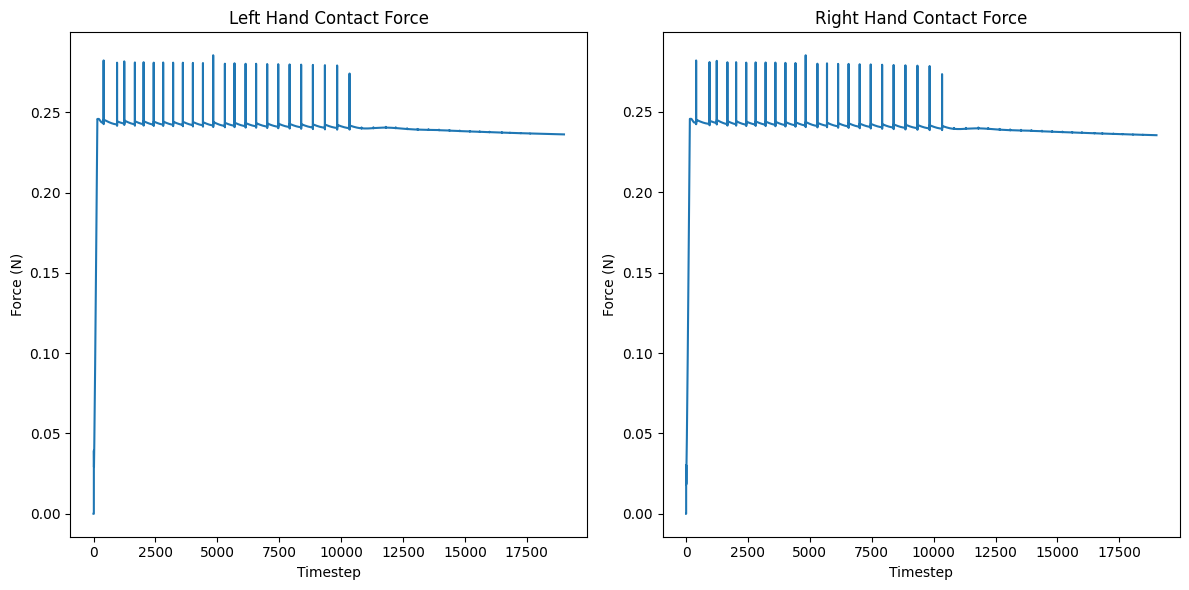

In [17]:
# shape of cartesian_force_list 
print(f"cartesian_force_list length: {len(cartesian_force_list[0])}")

# plot cartesian forces
import matplotlib.pyplot as plt
forces_left = np.array([f[0] for f in cartesian_force_list])
forces_right = np.array([f[1] for f in cartesian_force_list])
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(forces_left)
plt.title("Left Hand Contact Force")
plt.xlabel("Timestep")
plt.ylabel("Force (N)")
plt.subplot(1, 2, 2)
plt.plot(forces_right)
plt.title("Right Hand Contact Force")
plt.xlabel("Timestep")
plt.ylabel("Force (N)")
plt.tight_layout()
plt.show()